In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('ORB_SLAM3/evaluation/')
from evaluate_ate_scale3 import *

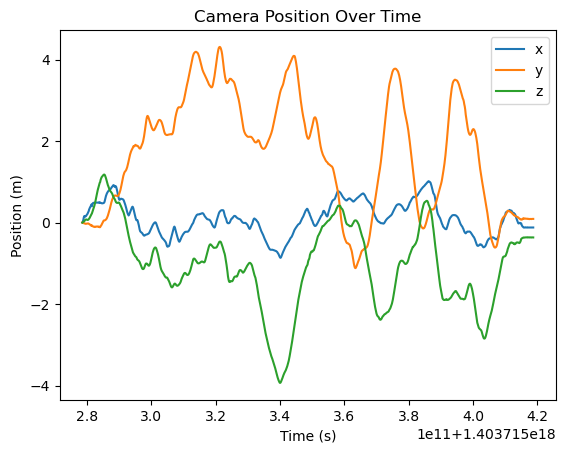

In [9]:
# Load data from ORB_SLAM3/f_dataset-V101_stereoi.txt

data = np.loadtxt('ORB_SLAM3/f_dataset-V101_stereoi.txt', delimiter=' ')

time = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

plt.plot(time, x, label='x')
plt.plot(time, y, label='y')
plt.plot(time, z, label='z')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Camera Position Over Time')
plt.legend()
plt.show()

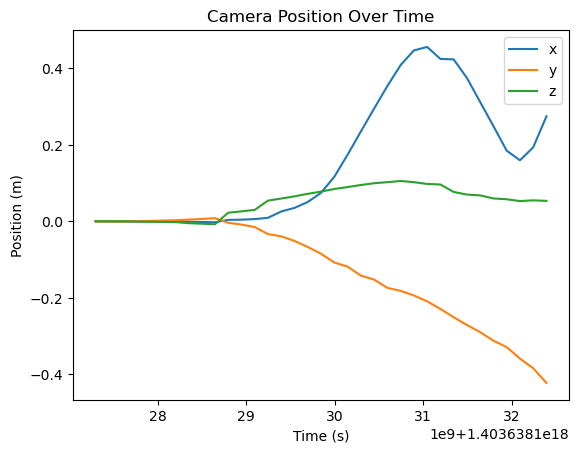

In [10]:
# Load data from stereo_msckf/track_output.txt

data = np.loadtxt('stereo_msckf/track_output.txt', delimiter=' ')

time = data[:, 0]
z = -data[:, 1]
y = data[:, 2]
x = data[:, 3]

plt.plot(time, x, label='x')
plt.plot(time, y, label='y')
plt.plot(time, z, label='z')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Camera Position Over Time')
plt.legend()
plt.show()

/tmp/nix-shell.pZK9KF/ipykernel_15807/764416770.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


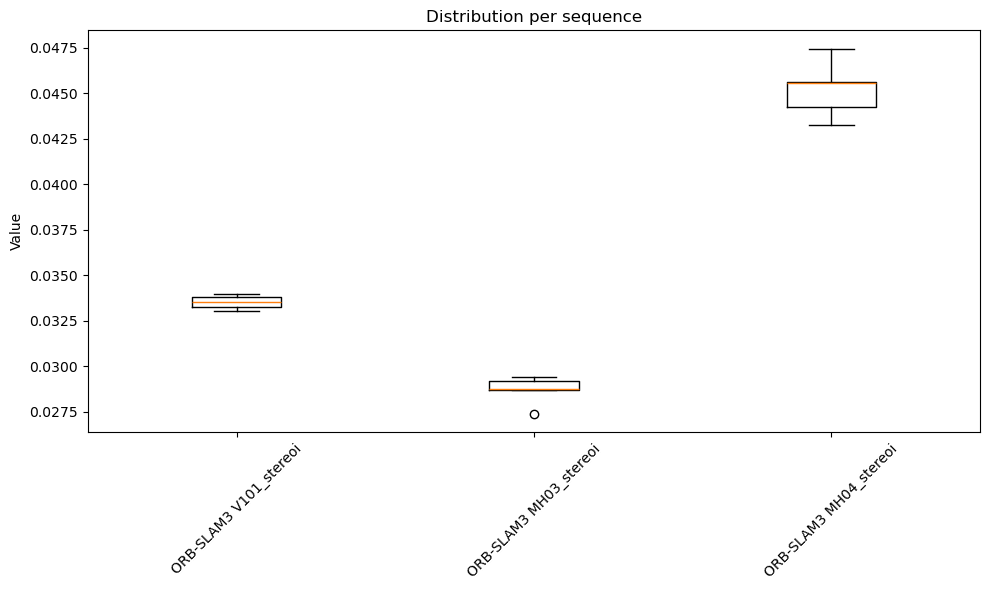

In [11]:
# Load data from ORB_SLAM3/output.txt and stereo_msckf/output.txt with numpy
# load index 0 as string

# Load data
orb_slam3_data = np.loadtxt('Outputs/ORB_baseline.txt', delimiter=',', dtype=str)
stereo_msckf_data = np.loadtxt('Outputs/MSCKF_baseline.txt', delimiter=',', dtype=str)
droid_data = np.loadtxt('Outputs/DROID_baseline.txt', delimiter=',', dtype=str)

lines_orb = {}
lines_stereo = {}

# Collect ORB-SLAM3 values
for i in range(len(orb_slam3_data)):
    key = orb_slam3_data[i, 1]
    if "mono" in key:
        continue

    val = float(orb_slam3_data[i, 4])
    lines_orb.setdefault(key, []).append(val)

# Collect Stereo-MSCKF values
for i in range(len(stereo_msckf_data)):
    key = stereo_msckf_data[i, 1]
    val = float(stereo_msckf_data[i, 4])
    lines_stereo.setdefault(key, []).append(val)

# Prepare boxplot data
labels = []
data = []

for key, value in lines_orb.items():
    labels.append(f"ORB-SLAM3 {key}")
    data.append(value)

#for key, value in lines_stereo.items():
#    labels.append(f"Stereo-MSCKF {key}")
#    data.append(value)

# Plot box and whisker diagram
plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=labels)

plt.xticks(rotation=45)
plt.ylabel("Value")
plt.title("Distribution per sequence")
plt.tight_layout()
plt.show()


In [12]:

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

df_orb = pd.DataFrame(orb_slam3_data, columns=["Date", "Sequence", "Raw ATE", "Scale", "RMS ATE", "%Compared", "fps", "duration"])
df_orb["Sequence"] = df_orb["Sequence"].apply(lambda x: x.split("_")[0] + " ORB")

df_msckf = pd.DataFrame(stereo_msckf_data, columns=["Date", "Sequence", "Raw ATE", "Scale", "RMS ATE", "%Compared", "fps", "duration"])
df_msckf["Sequence"] = df_msckf["Sequence"].apply(lambda x: x.split("_")[0] + " MSCKF")

df_droid = pd.DataFrame(droid_data, columns=["Date", "Sequence", "Raw ATE", "Scale", "RMS ATE", "%Compared", "fps", "duration"])
df_droid["Sequence"] = df_droid["Sequence"].apply(lambda x: x.split("_")[0] + " DROID")

df = pd.concat([df_droid], ignore_index=True)

df["RMS ATE"] = df["RMS ATE"].astype(float)
df["fps"] = df["fps"].astype(float)
#print(df)

fig = make_subplots(rows=1, cols=2, subplot_titles=("RMS ATE per Sequence", "FPS per Sequence"))

color_map = {
    "V101 ORB": "#21c626", "MH03 ORB": "#18971C", "MH04 ORB": "#07630A",
    "V101 DROID": "#f0ac2f", "MH03 DROID": "#C38B1D", "MH04 DROID": "#987107",
    "V101 MSCKF": "#429eff", "MH03 MSCKF": "#176BA6", "MH04 MSCKF": "#09579B"
}

# Left subplot
for seq, color in color_map.items():
    seq_df = df[df["Sequence"] == seq]
    fig.add_trace(go.Box(x=seq_df["Sequence"], y=seq_df["RMS ATE"], name=seq, marker_color=color, showlegend=False), row=1, col=1)

# Right subplot
fig.add_trace(go.Box(x=df["Sequence"], y=df["fps"], name="FPS", showlegend=False, marker_color="purple", ), row=1, col=2)

fig.update_yaxes(title_text="RMS ATE", col=1)
fig.update_yaxes(title_text="FPS", col=2)
fig.update_layout(title="Baseline performance per sequence for DROID SLAM")
fig.show()


# quick test to see if theres any correlation between fps and ate.
#fig2 = px.scatter(x=df["fps"], y=df["RMS ATE"])
#fig2.show()


In [13]:
# Get the mean FPS for each sequence and standard deviation for the RMS ATE
df_stats = df.groupby("Sequence").agg(
    mean_fps=("fps", "mean"),
    std_rms_ate=("RMS ATE", "std")
).reset_index()

print(df_stats)
print("Mean FPS: ", round(np.mean(df_stats["mean_fps"]), 2))
print("Mean RMS ATE: ", np.mean(df_stats["std_rms_ate"]))

     Sequence   mean_fps  std_rms_ate
0  MH03 DROID  59.868588     0.000054
1  MH04 DROID  76.501617     0.000095
2  V101 DROID  76.484675     0.000011
Mean FPS:  70.95
Mean RMS ATE:  5.302392464923235e-05


In [14]:
orb_slam3_stride = np.loadtxt('Outputs/ORB_stride.txt', delimiter=',', dtype=str)
orb_slam3_stride_corr = np.loadtxt('Outputs/ORB_stride_corrected.txt', delimiter=',', dtype=str)
stereo_msckf_stride = np.loadtxt('Outputs/MSCKF_stride.txt', delimiter=',', dtype=str)
droid_stride = np.loadtxt('Outputs/DROID_stride.txt', delimiter=',', dtype=str)

df = pd.DataFrame()
targets = {" ORB": orb_slam3_stride, " DROID": droid_stride, " MSCKF": stereo_msckf_stride }

for i in range(0, 150, 15):
  for key, value in targets.items():
    start = int(2 * i / 5 if key == " MSCKF" else i)
    stop = int(start + 6 if key == " MSCKF" else start + 15)
    #print(f"Processing {key} from index {start} to {stop}")
    df_temp = pd.DataFrame(value[start:stop, :], columns=["Date", "Sequence", "Raw ATE", "Scale", "RMS ATE", "Compared", "fps", "duration"])
    df_temp["Sequence"] = df_temp["Sequence"].apply(lambda x: x.split("_")[0] + key)
    stride = (i // 15) + 1
    df_temp["Stride"] = stride
    df_temp["Compared"] = df_temp["Compared"].astype(float)
    df_temp["Complete"] = df_temp["Compared"] * 10 if key == " DROID" else 100 * df_temp["Compared"] / (10 / stride)
    
    df_temp["fps"] = df_temp["fps"].astype(float)
    df_temp["fps"] = df_temp["fps"] * (float(stride) if key != " DROID" else 1.0)
    
    #print(10 / stride)

    df = pd.concat([df, df_temp], ignore_index=True)

df["RMS ATE"] = df["RMS ATE"].astype(float)



agg = (
    df.groupby(["Sequence", "Stride"])
    .agg(completeness_mean=("Complete", "mean"), mean=("RMS ATE", "mean"))
    .reset_index()
)

"""
agg = (
    df.groupby(["Sequence", "Stride"])["RMS ATE"]
    .agg(
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

agg["err_plus"] = agg["q3"] - agg["median"]
agg["err_minus"] = agg["median"] - agg["q1"]

"""
agg.loc[agg["completeness_mean"] <= 80, "mean"] = np.nan

fig = px.line(
    agg,
    x="Stride",
    y="mean",
    color="Sequence",
    markers=True,
    color_discrete_map={
  "V101 ORB": "#21c626", 
  "MH03 ORB": "#18971C",
  "MH04 ORB": "#07630A",
  "V101 MSCKF": "#429eff",
  "MH03 MSCKF": "#176BA6",
  "MH04 MSCKF": "#09579B",
  "V101 DROID": "#f0ac2f",
  "MH03 DROID": "#C38B1D",
  "MH04 DROID": "#987107",
  "V101 ORB C": "#c62121", 
  "MH03 ORB C": "#971818",
  "MH04 ORB C": "#630707",
}
)

fig.update_layout(
    yaxis_title="Completeness %",
    title="Completeness when varying stride per sequence and SLAM method"
)
fig.update_xaxes(dtick=1)
# Sort the legend order to be correct
cat_order = ["V101 ORB", "MH03 ORB", "MH04 ORB", "V101 MSCKF", "MH03 MSCKF", "MH04 MSCKF", "V101 DROID", "MH03 DROID", "MH04 DROID", "V101 ORB C", "MH03 ORB C", "MH04 ORB C"]
fig.data = tuple(sorted(fig.data, key=lambda t: int(cat_order.index(t.name))))

fig.show()




In [15]:
agg = (
    df.groupby(["Sequence", "Stride"])
    .agg(mean=("fps", "mean"), completeness_mean=("Complete", "mean"))
    .reset_index()
)

agg.loc[agg["completeness_mean"] <= 80, "mean"] = np.nan

fig = px.line(
    agg,
    x="Stride",
    y="mean",
    color="Sequence",
    markers=True,
    color_discrete_map={
  "V101 ORB": "#21c626", 
  "MH03 ORB": "#18971C",
  "MH04 ORB": "#07630A",
  "V101 MSCKF": "#429eff",
  "MH03 MSCKF": "#176BA6",
  "MH04 MSCKF": "#09579B",
  "V101 DROID": "#f0ac2f",
  "MH03 DROID": "#C38B1D",
  "MH04 DROID": "#987107",
  "V101 ORB C": "#c62121", 
  "MH03 ORB C": "#971818",
  "MH04 ORB C": "#630707",
}
)

fig.update_layout(
    yaxis_title="Effective FPS",
    title="Processing speed when varying stride per sequence and SLAM method"
)

# Sort the legend order to be correct
cat_order = ["V101 ORB", "MH03 ORB", "MH04 ORB", "V101 MSCKF", "MH03 MSCKF", "MH04 MSCKF", "V101 DROID", "MH03 DROID", "MH04 DROID", "V101 ORB C", "MH03 ORB C", "MH04 ORB C"]
fig.data = tuple(sorted(fig.data, key=lambda t: int(cat_order.index(t.name))))
fig.update_xaxes(dtick=1)
fig.update_yaxes(range=[0, None])
fig.show()


In [ ]:
droid_optim = np.loadtxt('Outputs/MSCKF_optim.txt', delimiter=',', dtype=str)

df = pd.DataFrame()
targets = {" MSCKF": droid_optim}

for i in range(15, 195, 15):
  for key, value in targets.items():
    start = int(2 * i / 5 if key == " MSCKF" else i)
    stop = int(start + 6 if key == " MSCKF" else start + 15)
    #print(f"Processing {key} from index {start} to {stop}")
    df_temp = pd.DataFrame(value[start:stop, :], columns=["Date", "Sequence", "Raw ATE", "Scale", "RMS ATE", "Compared", "fps", "duration"])
    df_temp["Sequence"] = df_temp["Sequence"].apply(lambda x: x.split("_")[0] + key)
    stride = 12 - (i // 15)
    df_temp["Stride"] = stride
    df_temp["Compared"] = df_temp["Compared"].astype(float)
    df_temp["Complete"] = df_temp["Compared"] * 10 if key == " DROID" else 100 * df_temp["Compared"] / (10 / 3)
    
    df_temp["fps"] = df_temp["fps"].astype(float)
    df_temp["fps"] = df_temp["fps"] * (float(3) if key != " DROID" else 1.0)
    
    #print(10 / stride)

    df = pd.concat([df, df_temp], ignore_index=True)

df["RMS ATE"] = df["RMS ATE"].astype(float)




agg = (
    df.groupby(["Sequence", "Stride"])
    .agg(completeness_mean=("Complete", "mean"), fps_mean=("fps", "mean"), mean=("RMS ATE", "mean"))
    .reset_index()
)

"""
agg = (
    df.groupby(["Sequence", "Stride"])["RMS ATE"]
    .agg(
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

agg["err_plus"] = agg["q3"] - agg["median"]
agg["err_minus"] = agg["median"] - agg["q1"]

"""
agg.loc[agg["completeness_mean"] <= 80, "mean"] = np.nan


print(agg.head(16))
fig = px.line(
    agg,
    x="Stride",
    y="fps_mean",
    color="Sequence",
    markers=True,
    color_discrete_map={
  "V101 ORB": "#21c626", 
  "MH03 ORB": "#18971C",
  "MH04 ORB": "#07630A",
  "V101 MSCKF": "#429eff",
  "MH03 MSCKF": "#176BA6",
  "MH04 MSCKF": "#09579B",
  "V101 DROID": "#f0ac2f",
  "MH03 DROID": "#C38B1D",
  "MH04 DROID": "#987107",
  "V101 ORB C": "#c62121", 
  "MH03 ORB C": "#971818",
  "MH04 ORB C": "#630707",
}
)

fig.update_layout(
    yaxis_title="Effective FPS",
    xaxis_title="Refinement iterations",
    title="Speed when varying refinement iterations per sequence for DROID SLAM",
    xaxis=dict(autorange="reversed")
)
#fig.update_yaxes(range=[0, None])
fig.update_xaxes()
# Sort the legend order to be correct
cat_order = ["V101 ORB", "MH03 ORB", "MH04 ORB", "V101 MSCKF", "MH03 MSCKF", "MH04 MSCKF", "V101 DROID", "MH03 DROID", "MH04 DROID", "V101 ORB C", "MH03 ORB C", "MH04 ORB C"]
fig.data = tuple(sorted(fig.data, key=lambda t: int(cat_order.index(t.name))))

fig.show()

      Sequence  Stride  completeness_mean   fps_mean      mean
0   MH03 MSCKF       1          100.03041  67.934037  0.146971
1   MH03 MSCKF       2          100.03041  66.725575  0.219063
2   MH03 MSCKF       3          100.03041  67.178622  0.139169
3   MH03 MSCKF       4          100.03041  64.415559  0.270977
4   MH03 MSCKF       5          100.03041  40.866782  3.566099
5   MH03 MSCKF       6          100.03041  64.337895  0.571263
6   MH03 MSCKF       7          100.03041  61.209700  0.211433
7   MH03 MSCKF       8          100.03041  59.782879  0.494137
8   MH03 MSCKF       9          100.03041  58.764769  1.376682
9   MH03 MSCKF      10          100.03041  59.763244  0.388679
10  MH03 MSCKF      11          100.03041  55.754213  0.266112
11  MH04 MSCKF       1          100.08606  67.653534  0.408062
12  MH04 MSCKF       2          100.08606  67.457449  0.408860
13  MH04 MSCKF       3          100.08606  67.085790  1.977320
14  MH04 MSCKF       4          100.08606  67.422630  1

In [41]:
# Some of the following code for extracting and aligning the bellow plot is borrowed from orb slam 3's eval script

gt_list   = associate.read_file_list("datasets/MH_04_difficult/mav0/state_groundtruth_estimate0/data.csv",   False)
est1_list = associate.read_file_list("stereo_msckf/track_output_fej.txt", False)
est2_list = associate.read_file_list("stereo_msckf/track_output_no_fej.txt", False)

matches1 = associate.associate(gt_list, est1_list, 0.0, 20000000)
matches2 = associate.associate(gt_list, est2_list, 0.0, 20000000)

# Match trajectory points
gt_xyz1 = np.matrix([[float(v) for v in gt_list[a][0:3]]   for a, b in matches1]).transpose()
gt_xyz2 = np.matrix([[float(v) for v in gt_list[a][0:3]]   for a, b in matches2]).transpose()

e1_xyz  = np.matrix([[float(v) * 1.0 for v in est1_list[b][0:3]] for a, b in matches1]).transpose()
e2_xyz  = np.matrix([[float(v) * 1.0 for v in est2_list[b][0:3]] for a, b in matches2]).transpose()

# Align to ground truth as best as possible
rot1, transGT1, trans_errorGT1, trans1, trans_error1, scale1 = align(e1_xyz, gt_xyz1)
rot2, transGT2, trans_errorGT2, trans2, trans_error2, scale2 = align(e2_xyz, gt_xyz2)

# Get trajectories for plotting
def full_xyz(file_list, scale=1.0):
    stamps = sorted(file_list.keys())
    return stamps, np.matrix([[float(v) * scale for v in file_list[s][0:3]] for s in stamps]).transpose()

gt_stamps,  gt_full  = full_xyz(gt_list)
e1_stamps,  e1_full  = full_xyz(est1_list, scale1)
e2_stamps,  e2_full  = full_xyz(est2_list, scale2)

e1_full_aligned = scale1 * rot1 * e1_full + trans1
e2_full_aligned = scale2 * rot2 * e2_full + trans2


gt_x,  gt_y  = np.asarray(gt_full[0]).flatten(),  np.asarray(gt_full[1]).flatten()
e1_x,  e1_y  = np.asarray(e1_full_aligned[0]).flatten(), np.asarray(e1_full_aligned[1]).flatten()
e2_x,  e2_y  = np.asarray(e2_full_aligned[0]).flatten(), np.asarray(e2_full_aligned[1]).flatten()

fig = go.Figure()

fig.add_trace(go.Scatter(x=gt_x, 
                         y=gt_y, 
                         mode="lines",
                         name="Ground Truth",
                         line=dict(color="#3BB900",   width=2)
                         ))

fig.add_trace(go.Scatter(x=e1_x,
                         y=e1_y, 
                         mode="lines", 
                         name=f"With FEJ (ATE={0.530:.3f} m)",
                         line=dict(color="#002B98", width=1.5)
                         ))

fig.add_trace(go.Scatter(x=e2_x, 
                         y=e2_y, 
                         mode="lines", 
                         name=f"Without FEJ (ATE={0.865:.3f} m)",
                         line=dict(color="#497AF9", width=1.5)
                         ))

fig.update_layout(
    height=800,
    title="Top-Down Trajectory Comparison of FEJ vs no FEJ for MSCKF SLAM on the MH04 Sequence",
    xaxis_title="x-axis (m)",
    yaxis_title="y-axis (m)",
    xaxis=dict(scaleanchor="y", scaleratio=1, tickfont=dict(size=16), title_font=dict(size=18)),
    legend=dict(x=0.01, y=0.99, font=dict(size=16)),
    yaxis=dict(tickfont=dict(size=16), title_font=dict(size=18)),
)

fig.show()